![DVD](../dvd_image.jpg)

A DVD rental company needs your help! They want to figure out how many days a customer will rent a DVD for based on some features and has approached you for help. They want you to try out some regression models which will help predict the number of days a customer will rent a DVD for. The company wants a model which yeilds a MSE of 3 or less on a test set. The model you make will help the company become more efficient inventory planning.

The data they provided is in the csv file `rental_info.csv`. It has the following features:

- `"rental_date"`: The date (and time) the customer rents the DVD.
- `"return_date"`: The date (and time) the customer returns the DVD.
- `"amount"`: The amount paid by the customer for renting the DVD.
- `"amount_2"`: The square of `"amount"`.
- `"rental_rate"`: The rate at which the DVD is rented for.
- `"rental_rate_2"`: The square of `"rental_rate"`.
- `"release_year"`: The year the movie being rented was released.
- `"length"`: Lenght of the movie being rented, in minuites.
- `"length_2"`: The square of "length".
- `"replacement_cost"`: The amount it will cost the company to replace the DVD.
- `"special_features"`: Any special features, for example trailers/deleted scenes that the DVD also has.
- `"NC-17"`, `"PG"`, `"PG-13"`, `"R"`: These columns are dummy variables of the rating of the movie. It takes the value 1 if the move is rated as the column name and 0 otherwise. For your convinience, the reference dummy has already been dropped.

Full reproducible pipeline (script) for the DVD rental duration project.
- Exploratory Data Analysis (EDA) with saved plots
- Preprocessing & feature engineering
- Feature selection (LassoCV) and model pipelines
- Hyperparameter tuning for RandomForest and GradientBoosting
- Stacking ensemble
- Evaluation on hold-out test set (MSE, RMSE, MAE, R2)
- SHAP explainability (global and a few local examples)
- Saves best pipeline to best_model.joblib and EDA/SHAP plots to ./outputs

Usage:
   1) Place `rental_info.csv` in the `'data'` folder.
   2) Create a virtualenv and install requirements from `requirements.txt` (suggested packages listed below).
   3) Run: python `rental_duration_analysis.py`

Notes:
- For SHAP on tree models, CPU time may be significant for large datasets.
- Outputs (plots, model) are saved in an outputs/ directory.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LassoCV, Ridge, LinearRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error as MAE, r2_score
import joblib

# SHAP
import shap

# Set aesthetic parameters for professional plots
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 9


In [2]:
# Defining functions

# Loading data
def load_data(path='../data/rental_info.csv'):
    df = pd.read_csv(path)
    return df

# Exploratory Data Analysis (EDA)
def eda(df):
    print('\n=== EDA Summary ===')
    print('Shape:', df.shape)
    print('\nMissing values:\n', df.isna().sum())
    print('\nData types:\n', df.dtypes)

    # rental length (computed)
    if 'return_date' in df.columns and 'rental_date' in df.columns:
        df['rental_date'] = pd.to_datetime(df['rental_date'])
        df['return_date'] = pd.to_datetime(df['return_date'])
        df['rental_length_days'] = (df['return_date'] - df['rental_date']).dt.total_seconds()/(24*3600)

    # Hist of target
    plt.figure(figsize=(12,6))
    sns.histplot(df['rental_length_days'].dropna(), kde=True, bins=30)
    plt.title('Distribution of rental_length_days')
    plt.savefig('../outputs/target_distribution.png', bbox_inches='tight', dpi=300)
    plt.show()

    # Log-transform distribution
    plt.figure(figsize=(12,6))
    sns.histplot(np.log1p(df['rental_length_days'].clip(lower=0)), kde=True, bins=30)
    plt.title('Distribution of log1p(rental_length_days)')
    plt.savefig('../outputs/target_log_distribution.png', bbox_inches='tight', dpi=300)
    plt.show()

    # Pairwise numeric correlations (subset)
    corr = df.select_dtypes(include=[np.number]).corr()
    annot = corr.round(2).astype(str).values

    plt.figure(figsize=(12,10), dpi=300)
    ax = sns.heatmap(corr, annot=False, fmt="", cmap="coolwarm",
                 linewidths=0.4, linecolor='white', cbar_kws={'shrink':0.6})

    # compute text color per cell based on normalized cell value
    # get colormap normalization used by the heatmap
    cmap = plt.get_cmap('coolwarm')
    # Use the same normalization seaborn used; ax.collections[0] is the QuadMesh
    mesh = ax.collections[0]
    vmin, vmax = mesh.get_clim()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    nrows, ncols = corr.shape
    for i in range(nrows):
        for j in range(ncols):
            val = corr.values[i, j]
            txt = annot[i, j]
            # choose text color with good contrast: white for dark cells, black for light cells
            rgba = cmap(norm(val))
            # perceived luminance approximation: 0.299*R + 0.587*G + 0.114*B
            lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = 'black' if lum > 0.5 else 'white'
            ax.text(j + 0.5, i + 0.5, txt, ha='center', va='center', fontsize=10, color=text_color)

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.title('Numeric feature correlation matrix')
    plt.tight_layout()
    plt.savefig('../outputs/correlation_matrix.png', bbox_inches='tight', dpi=300)
    plt.show()

    print('EDA plots saved to outputs/')

# Preprocessing the data for analyzing correctly
def preprocess_dates(df):
    df = df.copy()
    df['rental_date'] = pd.to_datetime(df['rental_date'])
    df['return_date'] = pd.to_datetime(df['return_date'])
    df['rental_length_days'] = (df['return_date'] - df['rental_date']).dt.total_seconds()/(24*3600)
    # date features from rental_date only (no leakage)
    df['rental_hour'] = df['rental_date'].dt.hour
    df['rental_dayofweek'] = df['rental_date'].dt.dayofweek
    df['rental_month'] = df['rental_date'].dt.month
    df['rental_year'] = df['rental_date'].dt.year
    return df

# Splitting special features into different categories
def special_flags(df):
    df = df.copy()
    df['deleted_scenes'] = df['special_features'].fillna('').str.contains('Deleted Scenes', regex=False).astype(int)
    df['behind_the_scenes'] = df['special_features'].fillna('').str.contains('Behind the Scenes', regex=False).astype(int)
    return df

# Preparing the features and labels for modeling
def build_X_y(df):
    drop_cols = ['special_features', 'rental_date', 'return_date', 'rental_length']
    X = df.drop(columns=drop_cols + ['rental_length_days'], errors='ignore')
    y = df['rental_length_days'].astype(float)
    return X, y

# Preparing the pipelines for modeling
def make_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    # drop potential identifier columns
    for c in ['id', 'rental_id', 'customer_id']:
        if c in numeric_cols:
            numeric_cols.remove(c)
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    # If there are boolean/int flags (NC-17, PG...) they are numeric already

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ], remainder='drop')

    return preprocessor, numeric_cols, categorical_cols

# Main function
def main(csv_path='../data/rental_info.csv'):
    df = load_data(csv_path)
    eda(df.copy())

    df = preprocess_dates(df)
    df = special_flags(df)

    X, y = build_X_y(df)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

    preprocessor, numeric_cols, categorical_cols = make_preprocessor(X_train)

    # Feature selector: LassoCV
    lasso = LassoCV(cv=5, random_state=RANDOM_STATE)
    selector = SelectFromModel(lasso)

    def pipe_for(model):
        return Pipeline([
            ('preproc', preprocessor),
            ('select', selector),
            ('model', model)
        ])

    # Candidate simple models
    ridge_pipe = pipe_for(Ridge(random_state=RANDOM_STATE))
    lr_pipe = pipe_for(LinearRegression())

    # Quick CV comparison
    print('\nRunning CV comparison on training set...')
    candidates = {'Ridge': ridge_pipe, 'LinearRegression': lr_pipe}
    for name, pipe in candidates.items():
        scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        print(f'{name}: CV MSE = {-scores.mean():.4f} (std {scores.std():.4f})')

    # Hyperparameter tuning for tree models
    rf_pipeline = pipe_for(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    gbr_pipeline = pipe_for(GradientBoostingRegressor(random_state=RANDOM_STATE))

    rf_param_dist = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 5, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 0.3]
    }

    gbr_param_dist = {
        'model__n_estimators': [100,200,300],
        'model__learning_rate': [0.01,0.05,0.1],
        'model__max_depth': [3,5,7],
        'model__subsample': [0.6,0.8,1.0]
    }

    print('\nTuning RandomForest...')
    rf_search = RandomizedSearchCV(rf_pipeline, rf_param_dist, n_iter=20, cv=4, scoring='neg_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1)
    rf_search.fit(X_train, y_train)
    print('RF best params:', rf_search.best_params_)
    print('RF best CV MSE:', -rf_search.best_score_)

    print('\nTuning GradientBoosting...')
    gbr_search = RandomizedSearchCV(gbr_pipeline, gbr_param_dist, n_iter=20, cv=4, scoring='neg_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1)
    gbr_search.fit(X_train, y_train)
    print('GBR best params:', gbr_search.best_params_)
    print('GBR best CV MSE:', -gbr_search.best_score_)

    # Build stacking with model-only estimators (use tuned params)
    def _strip_model_params(param_dict):
        return {k.replace('model__', ''): v for k, v in param_dict.items() if k.startswith('model__')}

    rf_params = _strip_model_params(rf_search.best_params_)
    gbr_params = _strip_model_params(gbr_search.best_params_)

    rf_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **rf_params)
    gbr_model = GradientBoostingRegressor(random_state=RANDOM_STATE, **gbr_params)

    stacker = StackingRegressor(estimators=[('rf', rf_model), ('gbr', gbr_model)], final_estimator=Ridge(), n_jobs=-1)

    # Final stack pipeline: preproc -> selector -> stacker
    stack_pipeline = Pipeline([
        ('preproc', preprocessor),
        ('select', selector),
        ('stack', stacker)
    ])

    # Fit all final models
    print('\nFitting final models on full training set...')
    final_models = {
        'RandomForest_tuned_pipeline': rf_search.best_estimator_,
        'GradientBoosting_tuned_pipeline': gbr_search.best_estimator_,
        'Stacking_pipeline': stack_pipeline,
        'Ridge_pipeline': ridge_pipe,
        'LinearRegression_pipeline': lr_pipe
    }

    for name, model in final_models.items():
        print('Fitting', name)
        model.fit(X_train, y_train)

    # Evaluate on test set
    results = {}
    for name, model in final_models.items():
        y_pred = model.predict(X_test)
        mse = MSE(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = MAE(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results[name] = {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
        print(f"\n{name} test: MSE={mse:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

    best_name = min(results, key=lambda k: results[k]['mse'])
    best_model = final_models[best_name]
    best_mse = results[best_name]['mse']
    best_rmse = results[best_name]['rmse']
    best_mae = results[best_name]['mae']
    best_r2 = results[best_name]['r2']
    print(f"\nBest model: {best_name}, with test MSE={best_mse:.4f}, RMSE={best_rmse:.4f}, MAE={best_mae:.4f}, R2={best_r2:.4f}")

    # Persist best model
    joblib.dump(best_model, '../outputs/best_model.joblib')
    print('Saved best_model.joblib to outputs/')

    # ---------------- SHAP explainability ----------------
    # Use TreeExplainer for tree models, KernelExplainer for others. We'll attempt to use TreeExplainer
    print('\nStarting SHAP explainability...')
    try:
        # We need a model that is a pipeline. For SHAP, we'll explain the model after preprocessing.
        # Create a function to get transformed train data and a prediction function over transformed data
        # If the best_model is a pipeline, separate preprocessor+selector and underlying estimator
        if isinstance(best_model, Pipeline):
            # preproc+select -> estimator
            # Transform X_train via preproc+select
            preproc = best_model.named_steps.get('preproc') if 'preproc' in best_model.named_steps else None
            select = best_model.named_steps.get('select') if 'select' in best_model.named_steps else None
            estimator = None
            # if stack pipeline, estimator is named 'stack' or 'model'
            if 'stack' in best_model.named_steps:
                estimator = best_model.named_steps['stack']
            elif 'model' in best_model.named_steps:
                estimator = best_model.named_steps['model']

            if preproc is None:
                raise RuntimeError('Pipeline does not have preproc step for shap')

            X_train_trans = preproc.transform(X_train)
            if select is not None:
                X_train_trans = select.transform(X_train_trans)

            # If estimator is a stacking regressor, we can use a TreeExplainer for the underlying tree models by wrapping predict
            # We'll try a sampler-based SHAP explainer appropriate to the estimator type
            try:
                explainer = shap.Explainer(best_model.predict, X_train)
                shap_values = explainer(X_test)

                # summary plot (global)
                plt.figure(figsize=(8,6))
                shap.summary_plot(shap_values, X_test, show=False)
                plt.savefig('../outputs/shap_summary.png', bbox_inches='tight', dpi=300)
                plt.show()
                print('Saved SHAP summary to outputs/shap_summary.png')

                # save a local explanation for the first test instance
                i = 0
                plt.figure(figsize=(8,4))
                shap.plots.waterfall(shap_values[i], show=False)
                plt.savefig(f'../outputs/shap_waterfall_{i}.png', bbox_inches='tight', dpi=300)
                plt.show()
                print(f'Saved SHAP waterfall for test instance {i} to outputs/')

            except Exception as e:
                print('SHAP Explainer failed with pipeline.predict directly, attempting model-level explainers. Error:', e)
                # Fall back: if estimator is tree-based use TreeExplainer on estimator with transformed data
                if hasattr(estimator, 'estimators_') or isinstance(estimator, (RandomForestRegressor, GradientBoostingRegressor)):
                    # explain using TreeExplainer on the full pipeline by creating predict function on raw X
                    explainer = shap.Explainer(best_model.predict, X_train)
                    shap_values = explainer(X_test)
                    plt.figure(figsize=(8,6))
                    shap.summary_plot(shap_values, X_test, show=False)
                    plt.savefig('../outputs/shap_summary_fallback.png', bbox_inches='tight', dpi=300)
                    plt.show()
                    print('Saved fallback SHAP summary to outputs/shap_summary_fallback.png')
        else:
            # best_model is not a pipeline but a model - try direct TreeExplainer
            explainer = shap.Explainer(best_model.predict, X_train)
            shap_values = explainer(X_test)
            plt.figure(figsize=(8,6))
            shap.summary_plot(shap_values, X_test, show=False)
            plt.savefig('../outputs/shap_summary.png', bbox_inches='tight', dpi=300)
            plt.show()
            print('Saved SHAP summary to outputs/shap_summary.png')

    except Exception as e:
        print('SHAP analysis failed:', e)
        print('You can run SHAP in a notebook interactively if issues occur. Continue...')

    print('\nAll done. Check the outputs/ directory for plots and outputs.')
    return best_model, best_mse, results



=== EDA Summary ===
Shape: (15861, 15)

Missing values:
 rental_date         0
return_date         0
amount              0
release_year        0
rental_rate         0
length              0
replacement_cost    0
special_features    0
NC-17               0
PG                  0
PG-13               0
R                   0
amount_2            0
length_2            0
rental_rate_2       0
dtype: int64

Data types:
 rental_date          object
return_date          object
amount              float64
release_year        float64
rental_rate         float64
length              float64
replacement_cost    float64
special_features     object
NC-17                 int64
PG                    int64
PG-13                 int64
R                     int64
amount_2            float64
length_2            float64
rental_rate_2       float64
dtype: object


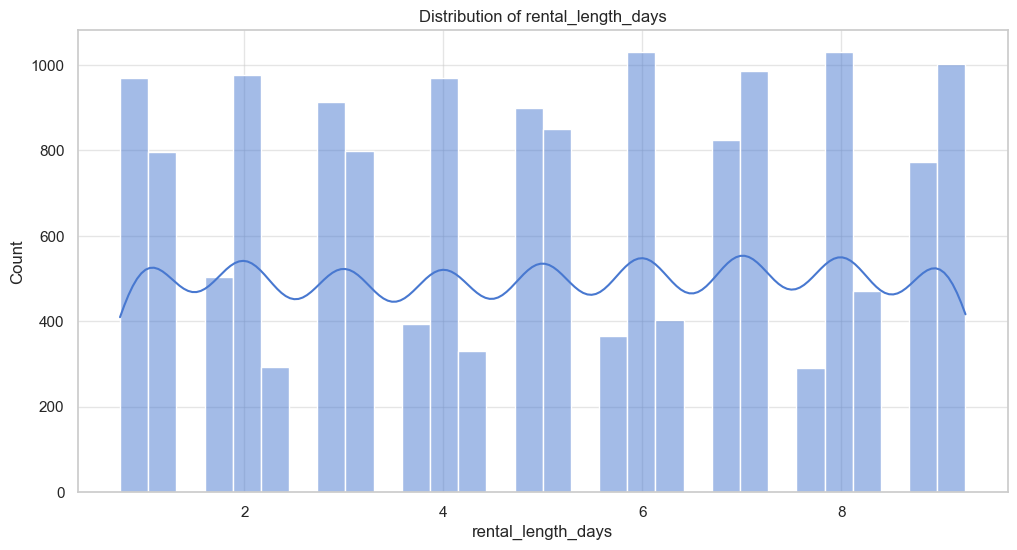

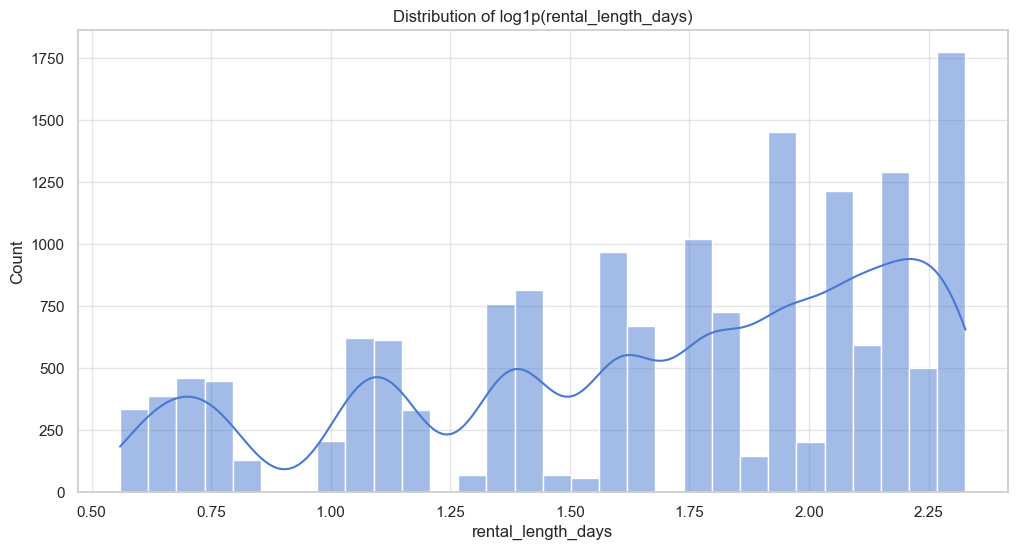

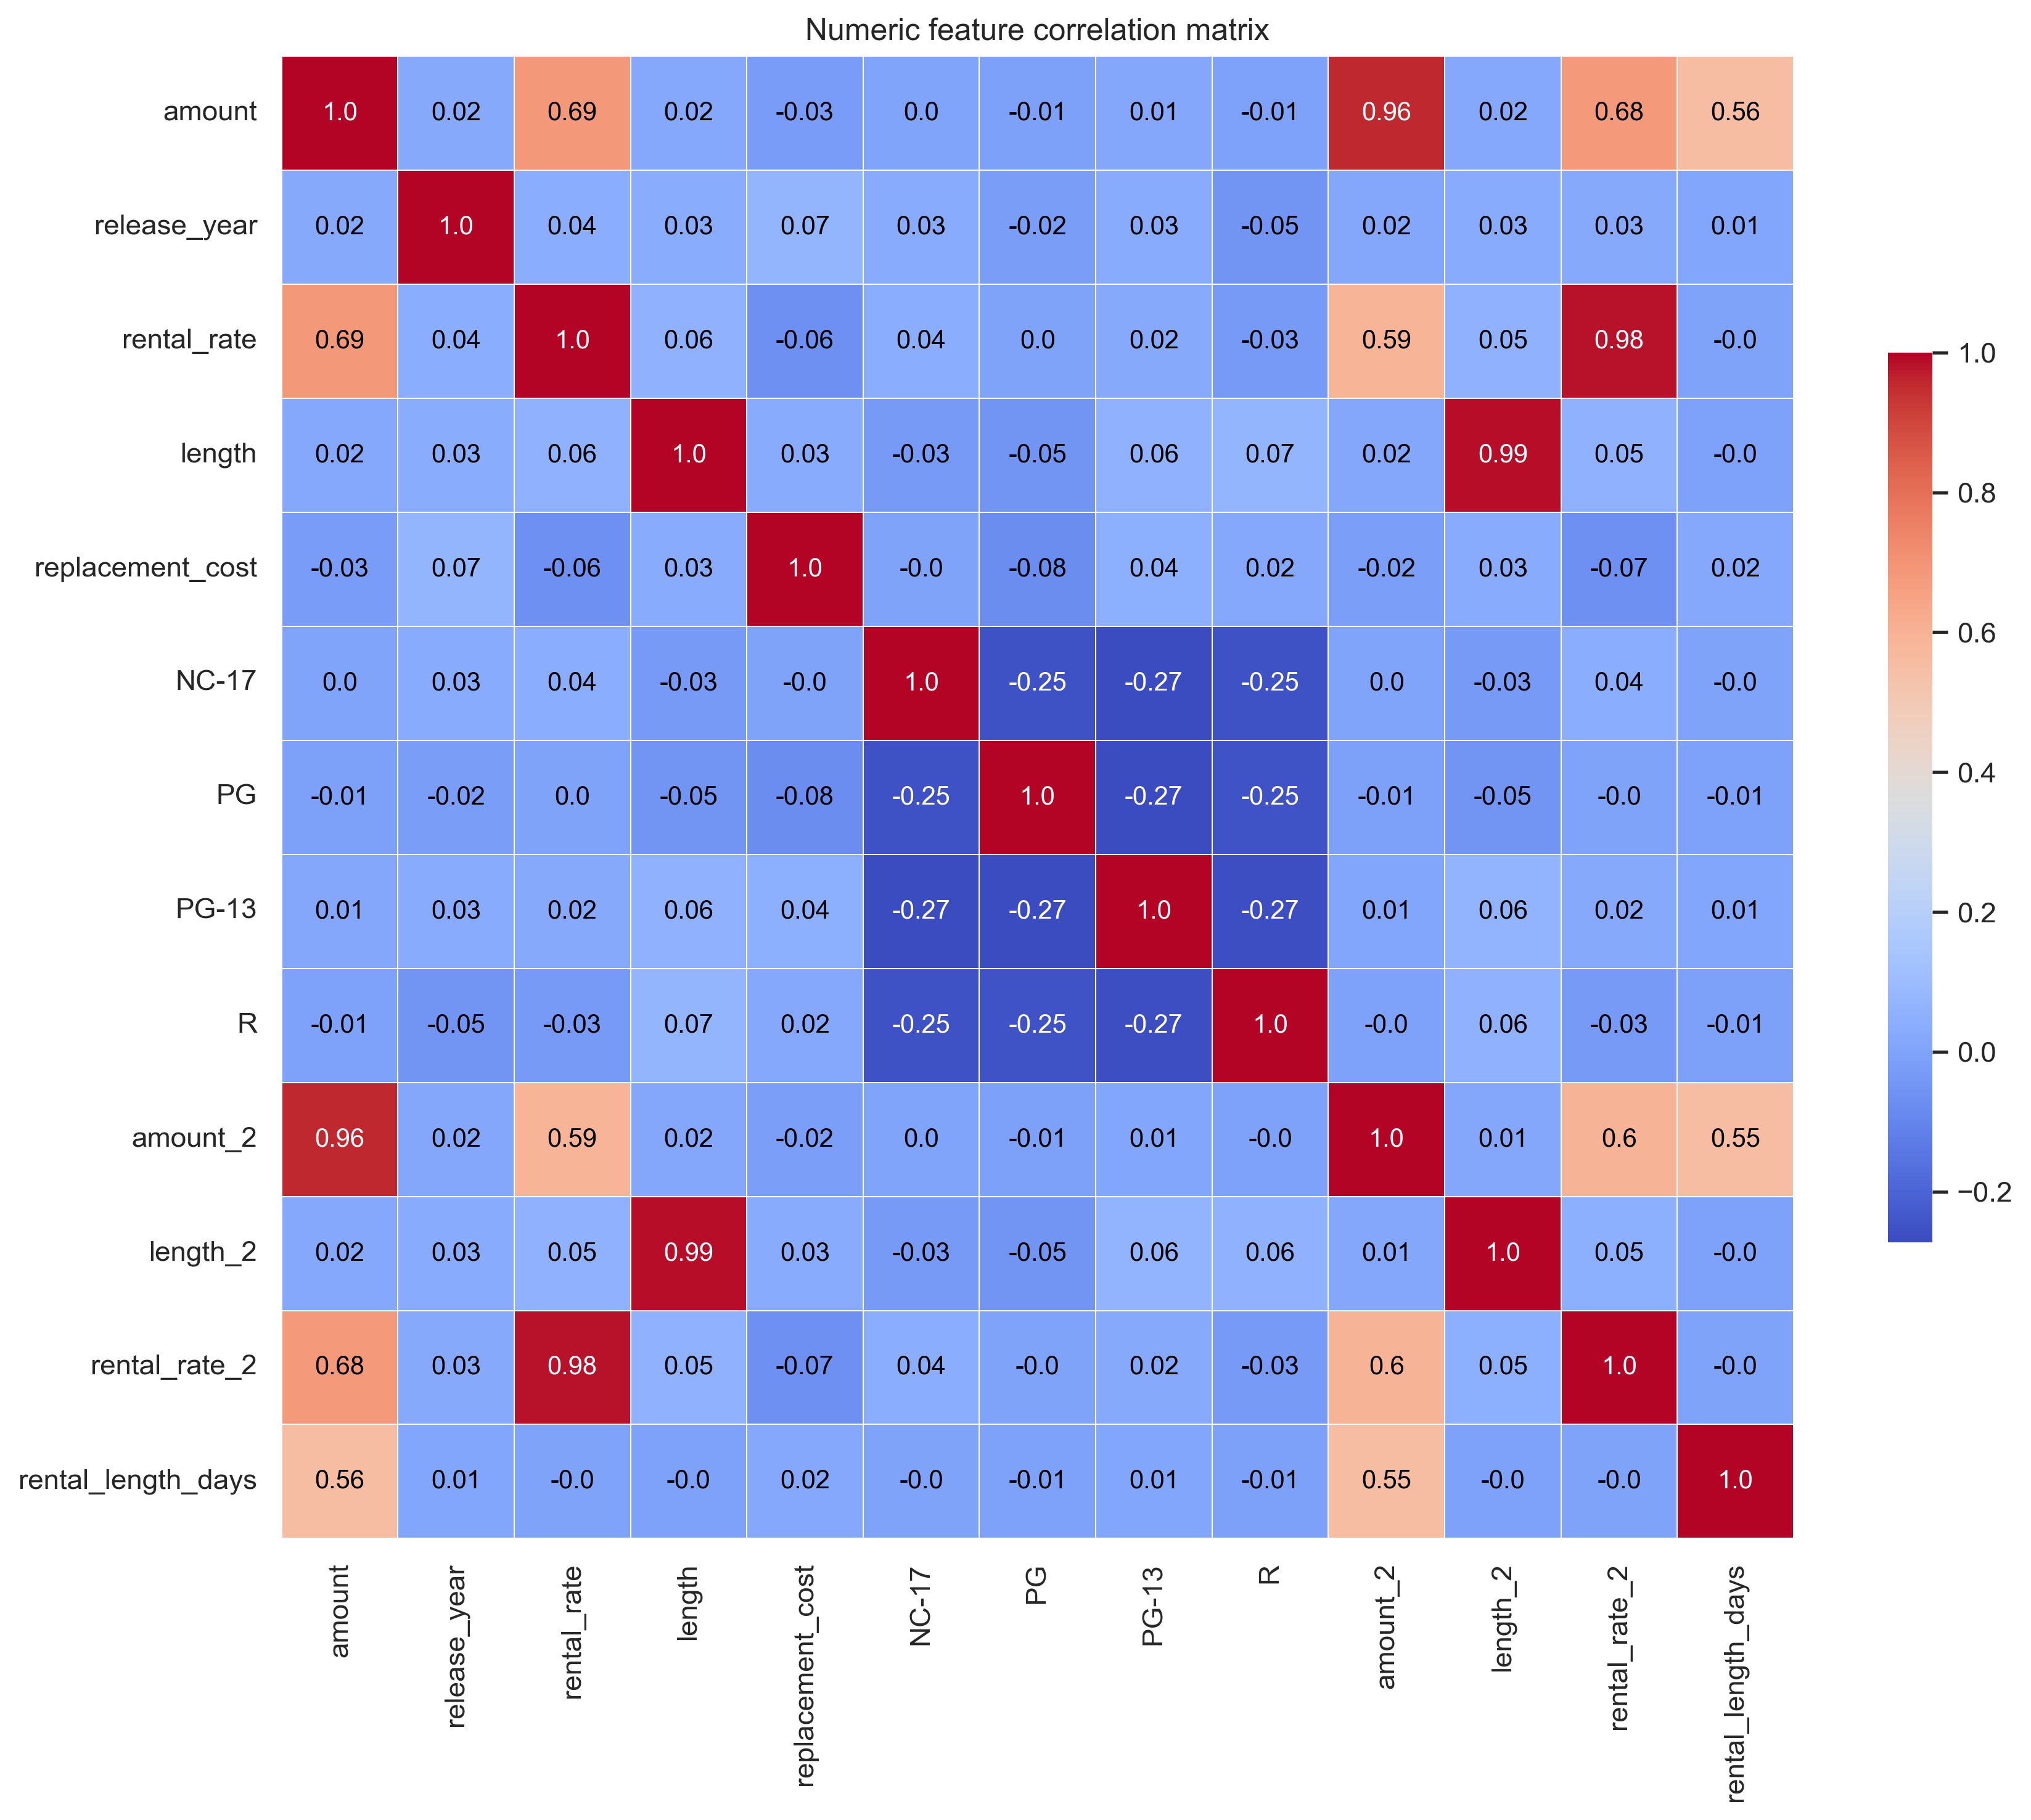

EDA plots saved to outputs/

Running CV comparison on training set...
Ridge: CV MSE = 2.6719 (std 0.0550)
LinearRegression: CV MSE = 2.6719 (std 0.0550)

Tuning RandomForest...
RF best params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}
RF best CV MSE: 2.022209411444544

Tuning GradientBoosting...
GBR best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1}
GBR best CV MSE: 1.8624651068462184

Fitting final models on full training set...
Fitting RandomForest_tuned_pipeline
Fitting GradientBoosting_tuned_pipeline
Fitting Stacking_pipeline
Fitting Ridge_pipeline
Fitting LinearRegression_pipeline

RandomForest_tuned_pipeline test: MSE=2.0210, RMSE=1.4216, MAE=1.1307, R2=0.7034

GradientBoosting_tuned_pipeline test: MSE=1.8572, RMSE=1.3628, MAE=1.0627, R2=0.7275

Stacking_pipeline test: MSE=1.8571, RMSE=1.3627, MAE=1.0641, R2=0.7

PermutationExplainer explainer: 3174it [21:01,  2.50it/s]                          


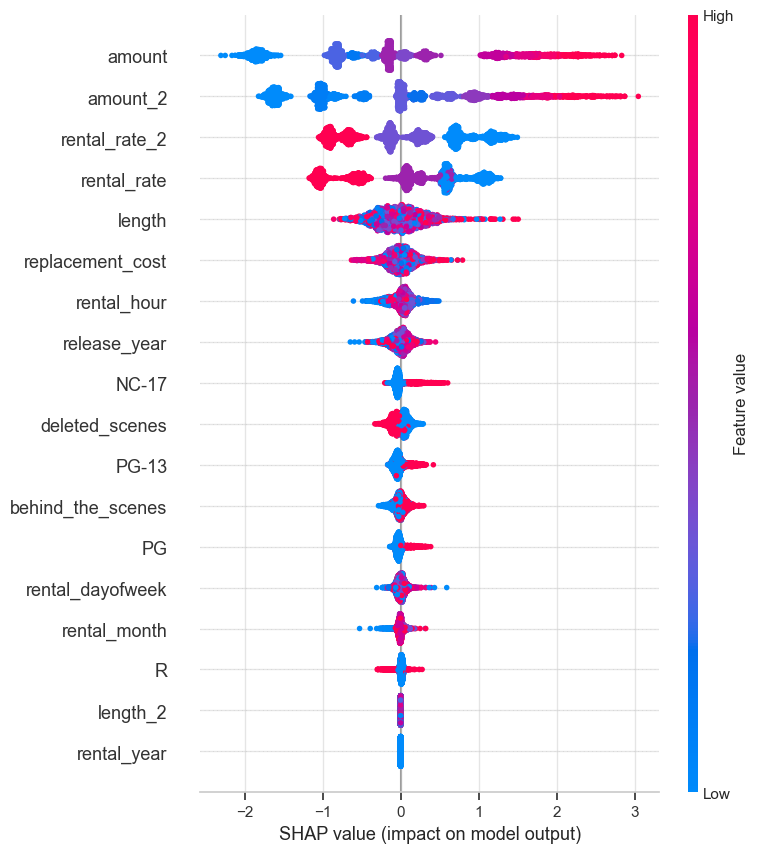

Saved SHAP summary to outputs/shap_summary.png


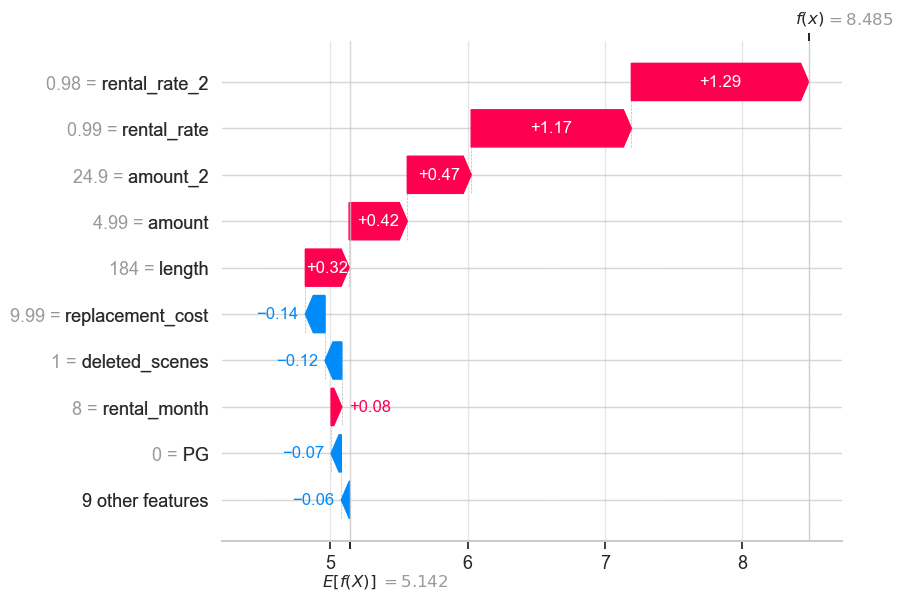

Saved SHAP waterfall for test instance 0 to outputs/

All done. Check the outputs/ directory for plots and outputs.

Finished. best_mse = 1.857051492939381


In [3]:
# Run the main function
if __name__ == '__main__':
    csv = '../data/rental_info.csv'
    if not Path(csv).exists():
        raise FileNotFoundError(f'{csv} not found. Place rental_info.csv in the data directory and re-run.')
    model, mse_val, metrics = main(csv)
    print('\nFinished. best_mse =', mse_val)